# A1.3 Phase portrait and behaviour of the SIRS model

With $r=N-s-i$, the two-dimensional system is

$$\frac{ds}{dt}=-R_0\frac{si}{N}+w(N-s-i),\qquad \frac{di}{dt}=R_0\frac{si}{N}-i.$$

## a. Trajectory and phase portrait
As given in Equation (4), $N=10^5$, $R_0=1.5$. The recovery rate is $\alpha=1$ as indicated in Part 1. 

For the phase portrait, we use $w=0.1$.

In [1]:

import numpy as np
import matplotlib.pyplot as plt

N = 100_000.0
R0 = 1.5

# Right-hand side of the SIRS model
def sirs_rhs(y, w):
    s, i = y
    infection = R0 * s * i / N
    return np.array([-infection + w * (N - s - i), infection - i])

# Right-hand side of the SIS model defined in Equation (2)
def sis_rhs(i):
    return (R0 - 1.0) * i - R0 * i * i / N

# Runge-Kutta 4th order method for solving ODEs
def rk4(rhs, y0, T, M):
    h = T / M 
    t = np.linspace(0.0, T, M + 1)
    y = np.empty((M + 1, len(np.asarray(y0, dtype=float))))
    y[0] = y0
    for k in range(M):
        yk = y[k]
        k1 = rhs(yk)
        k2 = rhs(yk + 0.5 * h * k1)
        k3 = rhs(yk + 0.5 * h * k2)
        k4 = rhs(yk + h * k3)
        y[k + 1] = yk + h * (k1 + 2*k2 + 2*k3 + k4) / 6.0
    return t, y

# Compute the long-term state of the SIRS model
def long_term_state(w):
    s_star = N / R0
    i_star = w * N * (1.0 - 1.0 / R0) / (1.0 + w)
    return np.array([s_star, i_star])

For the initial conditions, we chose some feasible states that represent different epidemic situations:

- $(s(0),i(0))=(N-10,10)$: mostly susceptible, using the assignment's default $i_0=10$ and assuming no recovered individuals initially.
- $(s(0),i(0))=(N-1000,1000)$: a larger initial outbreak, with no recovered individuals initially.
- $(s(0),i(0))=(0.70N,0.01N)$: a population with a substantial recovered group, since $r(0)=0.29N$.
- $(s(0),i(0))=(0.50N,0.10N)$: a population with an even larger recovered group, since $r(0)=0.40N$.

In every case, $r(0)=N-s(0)-i(0)\geq0$, so the initial condition is physically valid. 

We also chose $T=200$ and $M=20000$. This gives $h=T/M=0.01$, a sufficiently small RK4 step, and a long enough interval to display the damped oscillations before the trajectories settle near a long-term state.

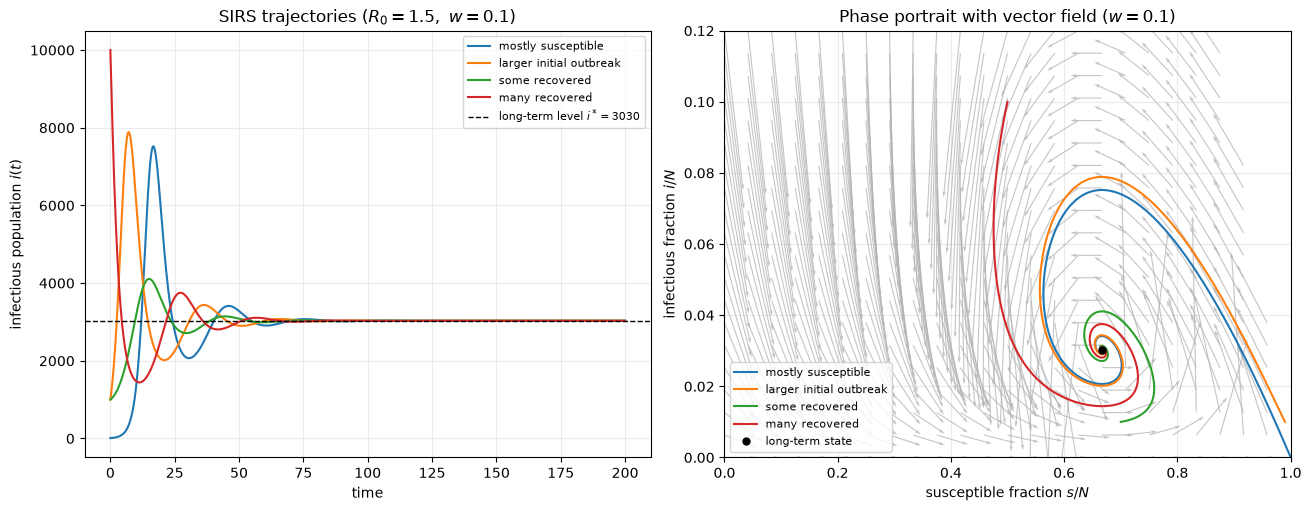

In [2]:
w = 0.1
T = 200.0
M = 20_000

initial_conditions = {
    'mostly susceptible': np.array([N - 10.0, 10.0]),
    'larger initial outbreak': np.array([N - 1_000.0, 1_000.0]),
    'some recovered': np.array([0.70 * N, 0.01 * N]),
    'many recovered': np.array([0.50 * N, 0.10 * N]),
}

# Integrate the model from every selected initial condition
trajectories = {
    label: rk4(lambda y, w=w: sirs_rhs(y, w), y0, T, M)
    for label, y0 in initial_conditions.items()
}

# Create the time-series plot and the phase portrait
fig, (ax_i, ax_phase) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for label, (t, y) in trajectories.items():
    ax_i.plot(t, y[:, 1], label=label)

# Add the predicted long-term infectious level for reference
i_star = long_term_state(w)[1]
ax_i.axhline(i_star, color='black', linestyle='--', linewidth=1,
             label=fr'long-term level $i^*={i_star:.0f}$')
ax_i.set(xlabel='time', ylabel='infectious population $i(t)$',
         title=r'SIRS trajectories ($R_0=1.5,\ w=0.1$)')
ax_i.grid(alpha=0.25)
ax_i.legend(fontsize=8)

# Vector field in normalized coordinates x=s/N and y=i/N
x = np.linspace(0.0, 1.0, 25)
yg = np.linspace(0.0, 0.12, 20)
Xg, Yg = np.meshgrid(x, yg)
U = -R0 * Xg * Yg + w * (1.0 - Xg - Yg)
V = R0 * Xg * Yg - Yg
feasible = Xg + Yg <= 1.0
speed = np.hypot(U, V)

U_plot = np.where(feasible, U / np.maximum(speed, 1e-12), np.nan)
V_plot = np.where(feasible, V / np.maximum(speed, 1e-12), np.nan)
ax_phase.quiver(Xg, Yg, U_plot, V_plot, color='0.70', alpha=0.75,
                angles='xy', scale_units='xy', scale=18, width=0.002)

for label, (t, y_state) in trajectories.items():
    ax_phase.plot(y_state[:, 0] / N, y_state[:, 1] / N, label=label)

long_term = long_term_state(w) / N
ax_phase.plot(*long_term, 'ko', markersize=5, label='long-term state')
ax_phase.set(xlabel=r'susceptible fraction $s/N$',
             ylabel=r'infectious fraction $i/N$',
             title=r'Phase portrait with vector field ($w=0.1$)',
             xlim=(0, 1), ylim=(0, 0.12))
ax_phase.grid(alpha=0.25)
ax_phase.legend(fontsize=8, loc='lower left')
plt.show()

In [3]:
# Compare h=0.01 with the smaller step h=0.005 to check that the results are consistent
for label, y0 in initial_conditions.items():
    _, fine = rk4(lambda y, w=w: sirs_rhs(y, w), y0, T, 2 * M)
    coarse = trajectories[label][1]
    max_difference = np.max(np.abs(coarse - fine[::2]))
    print(f'{label}: maximum difference = {max_difference:.3e}')

mostly susceptible: maximum difference = 2.826e-07
larger initial outbreak: maximum difference = 4.745e-08
some recovered: maximum difference = 2.488e-09
many recovered: maximum difference = 1.449e-08


### Interpretation

The disease-free state is $(s,i)=(N,0)$. When $i=0$, the infection term is zero, so this state remains on the $i=0$ boundary. For $R_0>1$ and $s$ close to $N$, the equation for $di/dt$ is positive for a small positive $i$, which agrees with the vector field pointing away from this boundary.

The long-term reference point is obtained by setting both right-hand sides of Eq. (8) to zero:

$$s^*=\frac{N}{R_0},\qquad i^*=\frac{w}{1+w}N\left(1-\frac{1}{R_0}\right).$$

For $w=0.1$, this gives $(s^*,i^*)=(66666.7,3030.3)$. The trajectories show damped oscillations around this point: $s(t)$ and $i(t)$ overshoot, then their oscillations decrease. The numerical step-size check above gives the same behaviour with $h=0.005$ as with $h=0.01$.

The two starts with no initially recovered individuals produce a large first outbreak because the susceptible population falls below $s^*=N/R_0$ before recovered individuals return to the susceptible class. The $(0.50N,0.10N)$ start has $s(0)<s^*$, so $i(t)$ initially decreases before the trajectory turns and spirals inward. The $(0.70N,0.01N)$ start is already close to the long-term point and therefore shows smaller oscillations. All four simulated trajectories approach the same point for these initial conditions. The phase-portrait axes show $s/N$ and $i/N$; the arrows are normalized to unit length and therefore show direction only.

## b. Increasing the waning rate

We compare SIRS with the SIS trajectory using $s(0)=N-10$, $i(0)=10$, and $r(0)=0$.

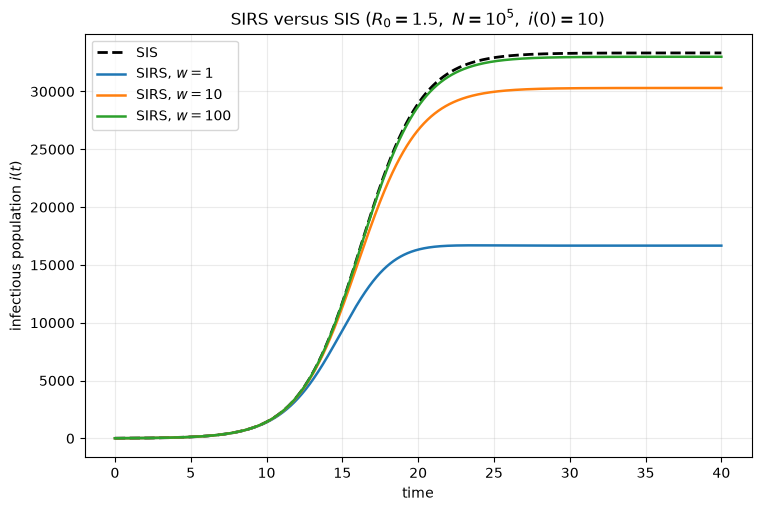

In [4]:
T_compare = 40.0
M_compare = 4_000
y0 = np.array([N - 10.0, 10.0])

# Compute the SIS reference trajectory
t_sis, sis_state = rk4(lambda z: np.array([sis_rhs(z[0])]), [10.0],
                         T_compare, M_compare)

fig, ax = plt.subplots(figsize=(7.5, 5), constrained_layout=True)
ax.plot(t_sis, sis_state[:, 0], 'k--', linewidth=2, label='SIS')

# Overlay SIRS trajectories for the three required waning rates
for w in (1.0, 10.0, 100.0):
    t, y_state = rk4(lambda y, w=w: sirs_rhs(y, w), y0,
                    T_compare, M_compare)
    ax.plot(t, y_state[:, 1], linewidth=1.8, label=fr'SIRS, $w={w:g}$')

ax.set(xlabel='time', ylabel='infectious population $i(t)$',
       title=r'SIRS versus SIS ($R_0=1.5,\ N=10^5,\ i(0)=10$)')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

In [5]:
print('SIS long-term level:', N * (1 - 1 / R0))
for w in (1.0, 10.0, 100.0):
    s_star, i_star = long_term_state(w)
    print(f'w={w:g}: s*={s_star:.1f}, i*={i_star:.1f}')

SIS long-term level: 33333.333333333336
w=1: s*=66666.7, i*=16666.7
w=10: s*=66666.7, i*=30303.0
w=100: s*=66666.7, i*=33003.3


### Interpretation

The SIS long-term level is $i^*_{\mathrm{SIS}}=33333.3$. For SIRS,

$$i^*_{\mathrm{SIRS}}=\frac{w}{1+w}i^*_{\mathrm{SIS}}.$$

The transient behaviour also changes with $w$. For $w=1$, the curve shows a small overshoot and undershoot around its long-term level. For $w=10$ and $w=100$, the curves rise without visible oscillations and become increasingly close to the SIS curve.

The recovered compartment becomes less important when $w$ is large. From Eq. (7), $dr/dt=i-wr$; increasing $w$ pulls recovered individuals back to the susceptible class more quickly. When waning is fast, $r$ remains small and approximately satisfies $wr\approx i$. Substituting this into Eq. (7) gives $ds/dt=-R_0si/N+i$ and $di/dt=R_0si/N-i$, which has the SIS form.

Therefore, $w=1$ gives a substantially lower long-term level, $w=10$ is closer to SIS, and $w=100$ nearly overlaps the SIS trajectory.

## AI Use Declaration

1. Did you use a generative AI tool? **Yes.**

2. How did you use generative AI? Select all that apply:
- writing or revising code;
- debugging code or interpreting error messages;
- interpreting data, results, tables, or plots;
- writing or revising explanations.

3. Sections/tasks: I used generative AI for code review and to refine my explanations. In Part (a), I also used it to help choose appropriate initial conditions and values for (T) and (M).

4. Verification: I checked the plots and long-term values with the suggested value, and reviewed the code and calculations.

5. I confirm that this declaration is complete and that I understand and can explain everything in my submission.